In [1]:
import os
import glob
import sys


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb  # Has to be imported first to avoid conflicts with PyROOT
import json
from time import time
from datetime import timedelta
from yaml import safe_load, YAMLError, dump
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc

import config as cfg
import efficiency_finder


In [2]:


# Function to load the BDT model from a JSON file
def load_bdt_model(json_path):
    bdt_model = xgb.Booster()
    bdt_model.load_model(json_path)
    return bdt_model

# Return list of variables to use in the bdt as a python list
def vars_fromyaml(path, bdtlist):
    with open(path) as stream:
        try:
            file = safe_load(stream)
            bdtvars = file[bdtlist]
        except YAMLError as exc:
            print(exc)
    return bdtvars


def dec2type( dec ):
    if dec in ["p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu", "p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu"]:
        return "signal"
    elif dec in ["p8_ee_Zbb_ecm91", "p8_ee_Zcc_ecm91"]:
        return "heavy"
    elif dec in ["p8_ee_Zss_ecm91","p8_ee_Zud_ecm91"]:
        return "light"
    elif dec in ["p8_ee_Zee_ecm91", "p8_ee_Zmumu_ecm91", "p8_ee_Ztautau_ecm91"]:
        return "lepton"
    else:
        return "unknown"


In [3]:
#######################################################
# Load BDT and apply to loaded data - define as funtion
#######################################################

def load_bdt_and_apply(pickled_df_fname = "bdth_dataframe.pkl", 
                        config_bdtopts = cfg.bdth_opts,
                        training_round = "baseline",
                        hps_dict_name = "default-hps",
                        features_list_name = "baseline-bdth-vars",
                        bdt_label = 'h'
                        ): # hps dict and features_list_name specift BDT used
    
    
    #path to data and outputs
    outputpath   = config_bdtopts['outputPath']
    yamlpath = cfg.fccana_opts['yamlPath']

    #Getting BDT vars for training from yaml
    bdtvars      = vars_fromyaml(yamlpath, features_list_name)
    bdtname      = f'BDT{bdt_label}_{hps_dict_name}_{features_list_name}'

    #path to pickled data
    pickled_df_path = os.path.join(outputpath, pickled_df_fname)

    #path to saved bdt
    bdt_json_path = os.path.join(outputpath,training_round,f"{bdtname}.json")

    # Load the BDT model
    try:
        print("Loading BDT model...")
        bdt_model = load_bdt_model(bdt_json_path)
        print("BDT model loaded successfully.")
    except Exception as e:
        print(f"Error loading BDT model: {e}")
        quit()

    # Read df saved to pickle and add BDT 

    #Getting BDT vars for training from yaml
    # load pickled df
    df = pd.read_pickle(pickled_df_path)

    #add bdt score
    df[f"bdt{bdt_label}_score"] =  bdt_model.predict(xgb.DMatrix(df[bdtvars])) #Add BDT1 score

    return bdt_model, bdtname, df


In [4]:
outputpath   = cfg.bdtl_opts['outputPath']
pickled_df_fname = "bdth_plus_dataframe.pkl"
#path to pickled data
pickled_df_path = os.path.join(outputpath, pickled_df_fname)
df = pd.read_pickle(pickled_df_path)

In [5]:
model, bdtname, dataframe = load_bdt_and_apply( pickled_df_fname = "bdth_plus_dataframe.pkl", 
                            config_bdtopts = cfg.bdtl_opts,
                            training_round = "baseline",
                            hps_dict_name = "default-hps",
                            features_list_name = "baseline-bdtl-vars",
                            bdt_label = 'l')


Loading BDT model...
BDT model loaded successfully.


In [6]:
bdt_json_path = '/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelim_cuts_noPV_ntracks_cut/bdth_outputs/baseline/BDTh_default-hps_baseline-bdth-vars.json'
bdt_model = load_bdt_model(bdt_json_path)

In [7]:
features_list_name='baseline-bdth-vars'
yamlpath = cfg.fccana_opts['yamlPath']
bdth_vars = vars_fromyaml(yamlpath, features_list_name)
dataframe[f"bdth_score"] =  bdt_model.predict(xgb.DMatrix(dataframe[bdth_vars]))

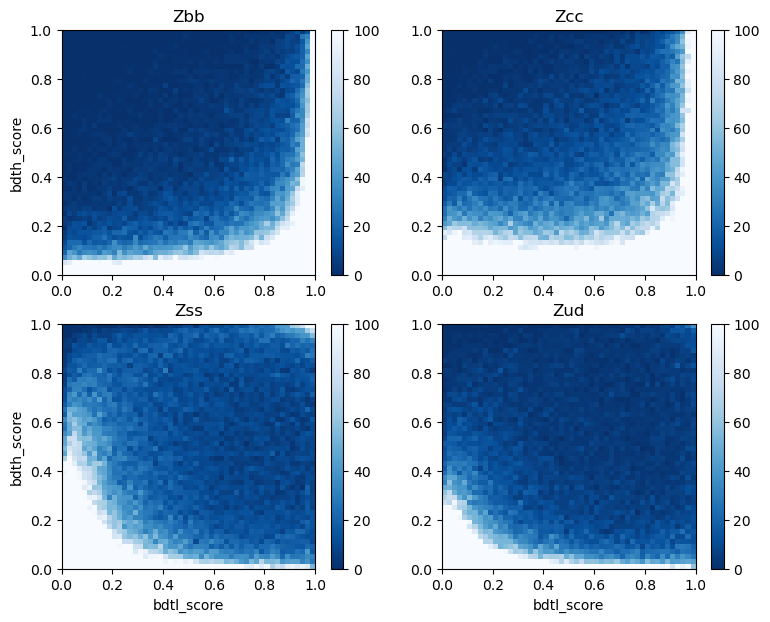

In [8]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(9,7))

df_bb = dataframe[dataframe['decay']=='p8_ee_Zbb_ecm91']
df_cc = dataframe[dataframe['decay']=='p8_ee_Zcc_ecm91']
df_ss = dataframe[dataframe['decay']=='p8_ee_Zss_ecm91'] 
df_ud = dataframe[dataframe['decay']=='p8_ee_Zud_ecm91'] 


# Big bins
axs[0, 0].set_title('Zbb')
axs[0,0].set_ylabel('bdth_score')
#axs[0, 0].set_xticklabels([])
 
# Small bins
axs[0, 1].set_title('Zcc')
#axs[0, 1].set_xticklabels([])
#axs[0, 1].set_yticklabels([])


axs[1, 0].set_title('Zss')
axs[1,0].set_xlabel('bdtl_score')
axs[1,0].set_ylabel('bdth_score')


axs[1, 1].set_title('Zud')
axs[1,1].set_xlabel('bdtl_score')
#axs[1, 1].set_yticklabels([])


h1 = axs[0, 0].hist2d(df_bb["bdtl_score"], df_bb["bdth_score"], bins=(50, 50), range=[ [0, 1],[0, 1]], cmap=plt.cm.Blues_r,vmin=0,vmax=100)
h2 = axs[0, 1].hist2d(df_cc["bdtl_score"], df_cc["bdth_score"], bins=(50, 50), range=[ [0, 1],[0, 1]], cmap=plt.cm.Blues_r,vmin=0,vmax=100)
h3 = axs[1, 0].hist2d(df_ss["bdtl_score"], df_ss["bdth_score"], bins=(50, 50), range=[ [0, 1],[0, 1]], cmap=plt.cm.Blues_r,vmin=0,vmax=100)
h4 = axs[1, 1].hist2d(df_ud["bdtl_score"], df_ud["bdth_score"], bins=(50, 50), range=[ [0, 1],[0, 1]], cmap=plt.cm.Blues_r,vmin=0,vmax=100)

# Visualizing colorbar 
fig.colorbar(h1[3], ax=axs[0, 0])
fig.colorbar(h2[3], ax=axs[0, 1])
fig.colorbar(h3[3], ax=axs[1, 0])
fig.colorbar(h4[3], ax=axs[1, 1])


plt.show()



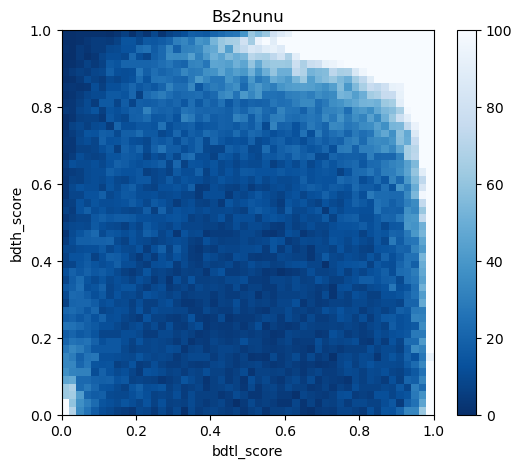

In [10]:
df_Bs = dataframe[dataframe['decay']=='p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu']

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(6,5))

# Big bins
h=axs.hist2d(df_Bs["bdtl_score"], df_Bs["bdth_score"], bins=(50, 50), range=[[0, 1],[0,1]], cmap=plt.cm.Blues_r,vmin=0,vmax=100)
axs.set_title('Bs2nunu')
axs.set_ylabel('bdth_score')
axs.set_xlabel('bdtl_score')



# Visualizing colorbar 
fig.colorbar(h[3], ax=axs)
plt.show()

## Effect of cut on BDTh

In [15]:
plt.style.use('fcc.mplstyle')

In [11]:
df_bdthcut = dataframe[dataframe['bdth_score']>0.9]

In [131]:
#Function to enable automatic xtitle with > or <
def replace_all(s, old_char, new_char):
    # Replace all occurrences of the old character with the new character
    s = s.replace(old_char, new_char)
    return s

def histogram_settings():
    
    hist_settings = { allocation: {} for allocation in cfg.sample_allocations }
    total_color = { allocation: {} for allocation in cfg.sample_allocations }

    for allocation in cfg.sample_allocations:
        samples = cfg.sample_allocations[allocation]
            
        if allocation=='Bssignal':
            hist_settings[allocation]['histtype'] = 'step'
            hist_settings[allocation]['lw'] = 2
            hist_settings[allocation]['color'] = plt.cm.Blues( np.linspace(0, 1, len(cfg.sample_allocations['combined_signal'])+4)[3]) #'cornflowerblue'
            hist_settings[allocation]['hatch'] = '////'
        elif allocation=='Bdsignal':
            hist_settings[allocation]['histtype'] = 'step'
            hist_settings[allocation]['lw'] = 2
            hist_settings[allocation]['color'] = plt.cm.Blues( np.linspace(0, 1, len(cfg.sample_allocations['combined_signal'])+4)[-2]) #'mediumblue'#'royalblue'
            hist_settings[allocation]['hatch'] = r'\\\\'
        elif allocation=='combined_signal':
            hist_settings[allocation]['histtype'] = 'step'
            hist_settings[allocation]['lw'] = 2
            hist_settings[allocation]['color'] =plt.cm.Blues( np.linspace(0, 1, len(samples)+4)[3:-1] ) #['cornflowerblue','mediumblue']#['cornflowerblue', 'dodgerblue',]#['cadetblue','teal']#['cornflowerblue','mediumblue']
            total_color[allocation] = 'midnightblue'
            #hist_settings[allocation]['hatch'] = "////"

        elif allocation=='hadronic_background':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['color'] = plt.cm.Reds_r( np.linspace(0, 1, len(samples)+2)[1:-1] )
            total_color[allocation] = 'k'
        elif allocation=='light_hadronic_background':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['color'] = plt.cm.Reds_r( np.linspace(0, 1, len(cfg.sample_allocations['hadronic_background'])+2)[3:-1] )
            total_color[allocation] = 'indianred'
        elif allocation=='heavy_hadronic_background':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['color'] = plt.cm.Reds_r( np.linspace(0, 1, len(cfg.sample_allocations['hadronic_background'])+2)[1:3] )
            total_color[allocation] = 'darkred'
        elif allocation=='bb_only':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['lw'] = 2
            hist_settings[allocation]['alpha'] = 0.6
            hist_settings[allocation]['color'] = plt.cm.Reds_r( np.linspace(0, 1, len(cfg.sample_allocations['hadronic_background'])+2)[1] )

        elif allocation=='tau_background':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['color'] = plt.cm.tab20b((4+ np.linspace(0, 1, len(cfg.sample_allocations['leptonic_background'])+2)[1])/5 )#'mediumvioletred'
            total_color[allocation] = 'indigo'
        elif allocation=='leptonic_background':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['color'] = plt.cm.tab20b( (4+np.linspace(0, 1, len(samples)+2)[1:-1]) /5 )# plt.cm.tab20b((4+ np.linspace(0, 1, len(samples)))/5 ) #plt.cm.PuRd_r( np.linspace(0, 1, len(samples)+2)[1:-1] ) 
            total_color[allocation] = 'indigo'#'purple'
        elif allocation=='light_leptonic_background':
            hist_settings[allocation]['histtype'] = 'stepfilled'
            hist_settings[allocation]['color'] = plt.cm.tab20b((4+ np.linspace(0, 1, len(cfg.sample_allocations['leptonic_background'])+2)[2:-1])/5 )
            total_color[allocation] = 'mediumvioletred'

    return hist_settings, total_color



In [132]:
def post_bdt_variable_plot(data,variable,
                           bdt_cut = None, #must be string of correct format as in vp
                           bdt_name = "BDTh",
                           weight=True,
                           density=True,
                           bins=50,
                           xrange=None,
                           stacked=True, 
                           total=["hadronic_background"], 
                           components=["Bssignal", "hadronic_background"], #currently not set up to do Bd and Bs with separate nominal bfs but thsi shouldnt be an issue
                           signal_bf=1e-6):


    decays_list = [cfg.sample_allocations[i] for i in components]
    flat_decays_list = [item for sublist in decays_list for item in sublist]


    if bdt_cut:
        df = data.copy().query(bdt_cut)
    else:
        df = data.copy()


    values = {sample: df[df['decay']==sample][variable].to_numpy() for sample in flat_decays_list}

    if xrange is None:
        xmin = min( [ min(values[sample]) for sample in values ] )
        xmax = max( [ max(values[sample]) for sample in values ] )
    else:
        xmin = xrange[0]
        xmax = xrange[1]

    # If variable is an integer make sure nbins correct
    #for most variables nbins=xmax-xmin
    #unless ChargedRP_fromPV_transformed
    if bins!=50:
        nbins = bins
    elif 'ChargedRP_fromPV_transformed' in variable:
        nbins=3
    elif '_n' in variable and '_norm' not in variable:
        print(variable)
        xmin = 0
        nbins= int(xmax - xmin)
    else:
        nbins=50

    fig, ax = plt.subplots()

    hist_settings,total_colours = histogram_settings()

    if weight: 
        desired_signal_samples = [sample for sample in cfg.sample_allocations['combined_signal'] if sample in flat_decays_list]
        for sample in desired_signal_samples:
            df.loc[df['decay'] == sample, 'w1']=df[df['decay']==sample]['w1']* 2*cfg.branching_fractions['p8_ee_Zbb_ecm91'][0]*cfg.prod_frac[sample][0]*signal_bf


        if density==False:
            ax.set_title(f'Assuming signal branching fraction = {signal_bf:.1e}')

    for allocation in cfg.sample_allocations:

        if allocation not in components:
            continue

        samples = cfg.sample_allocations[allocation]
        hist_x = [ values[sample] for sample in samples ]
        hist_l = [ cfg.titles[sample] for sample in samples ]
        hist_opts = hist_settings[allocation]
        tot_colour= total_colours[allocation]

        if weight:
            hist_w= [np.array(df[df['decay']==sample]['w1'])*6e12 for sample in samples]
            #print(variable)
            #print(hist_w)
        else:
            hist_w = None

        if stacked:
            hist_opts['stacked'] = True
        else:
            hist_opts['stacked'] = False

        ax.hist( 
            x = hist_x,
            bins = nbins,
            range = (xmin,xmax),
            density = density,
            label = hist_l,
            weights = hist_w,
            **hist_opts
        )
        if allocation =='combined_signal':
            ax.hist(
                x=hist_x,
                bins=nbins,
                range=(xmin, xmax),
                density=density,
                weights=hist_w,
                histtype='stepfilled',  # shading only
                color=hist_opts['color'],  # Fill color
                edgecolor='midnightblue',
                linewidth=2,
                hatch='////',
                stacked=hist_opts['stacked'],
                fill=False
            )

        if allocation in total and stacked:
            ax.hist( 
                np.concatenate( hist_x), 
                bins = nbins,
                range = (xmin,xmax),
                density = density,
                label = f'Total {allocation.replace("_", " ")}',
                weights = np.concatenate( hist_w ) if weight else None,
                histtype = 'step',
                color = tot_colour,#'k',
                lw = 2,
            )

    ax.legend(reverse=True)
                            



    if bdt_cut is not None:
        ax.set_xlabel(f"{variable} (cut={replace_all(replace_all(replace_all(bdt_cut,'>','$>$'),'<','$<$'),'&',',')})")
    else:
        ax.set_xlabel(f"{variable} (cut={bdt_cut})")

    if density:
        ax.set_ylabel('Density')
    else:
        ax.set_ylabel('Counts')
   

    fig.tight_layout()



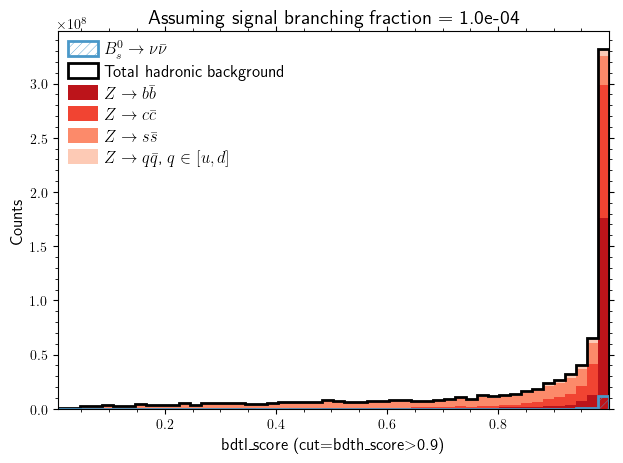

In [127]:
post_bdt_variable_plot(df_bdthcut,'bdtl_score',
                           bdt_cut = 'bdth_score>0.9', #must be string of correct format as in vp
                           bdt_name = "BDTh",
                           weight=True,
                           density=False,
                           bins=50,
                           xrange=None,
                           stacked=True, 
                           total=["hadronic_background"], 
                           components=["Bssignal", "hadronic_background"], #currently not set up to do Bd and Bs with separate nominal bfs but thsi shouldnt be an issue
                           signal_bf=1e-4)

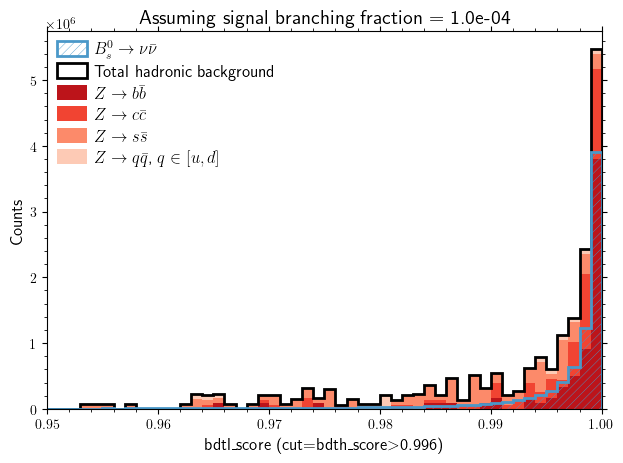

In [37]:
post_bdt_variable_plot(df_bdthcut,'bdtl_score',
                           bdt_cut = 'bdth_score>0.996', #must be string of correct format as in vp
                           bdt_name = "BDTh",
                           weight=True,
                           density=False,
                           bins=50,
                           xrange=(0.95,1),
                           stacked=True, 
                           total=["hadronic_background"], 
                           components=["Bssignal", "hadronic_background"], #currently not set up to do Bd and Bs with separate nominal bfs but thsi shouldnt be an issue
                           signal_bf=1e-4)

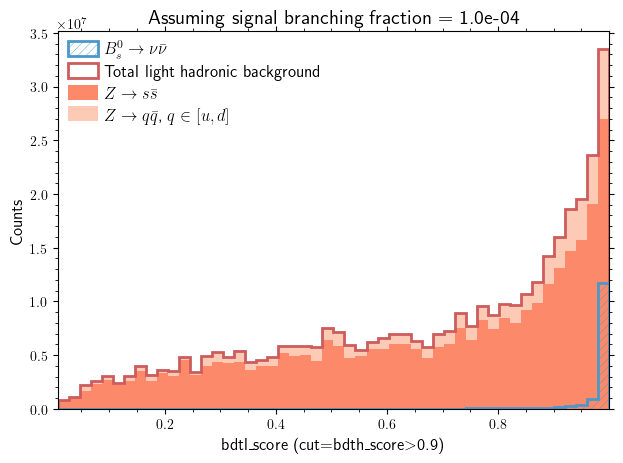

In [39]:
post_bdt_variable_plot(df_bdthcut,'bdtl_score',
                           bdt_cut = 'bdth_score>0.9', #must be string of correct format as in vp
                           bdt_name = "BDTh",
                           weight=True,
                           density=False,
                           bins=50,
                           xrange=None,
                           stacked=True, 
                           total=["light_hadronic_background"], 
                           components=["Bssignal", "light_hadronic_background"], #currently not set up to do Bd and Bs with separate nominal bfs but thsi shouldnt be an issue
                           signal_bf=1e-4)

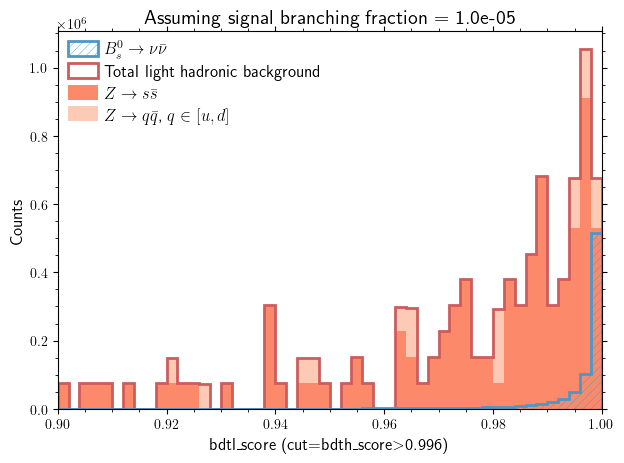

In [78]:
post_bdt_variable_plot(df_bdthcut,'bdtl_score',
                           bdt_cut = 'bdth_score>0.996', #must be string of correct format as in vp
                           bdt_name = "BDTh",
                           weight=True,
                           density=False,
                           bins=50,
                           xrange=(0.9,1),
                           stacked=True, 
                           total=["light_hadronic_background"], 
                           components=["Bssignal", "light_hadronic_background"], #currently not set up to do Bd and Bs with separate nominal bfs but thsi shouldnt be an issue
                           signal_bf=1e-5)

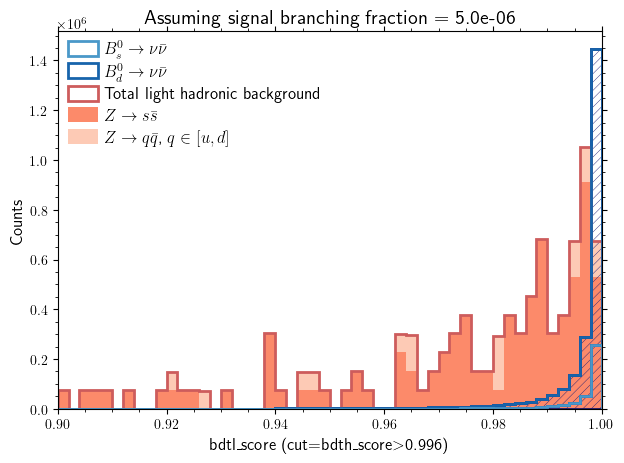

In [133]:
post_bdt_variable_plot(df_bdthcut,'bdtl_score',
                           bdt_cut = 'bdth_score>0.996', #must be string of correct format as in vp
                           bdt_name = "BDTh",
                           weight=True,
                           density=False,
                           bins=50,
                           xrange=(0.9,1),
                           stacked=True, 
                           total=["light_hadronic_background"], 
                           components=["combined_signal", "light_hadronic_background"], #currently not set up to do Bd and Bs with separate nominal bfs but thsi shouldnt be an issue
                           signal_bf=5e-6)

## looking at bdtl variables

KeyError: 'ln_Rec_track_absd0_max_hemisEmax'

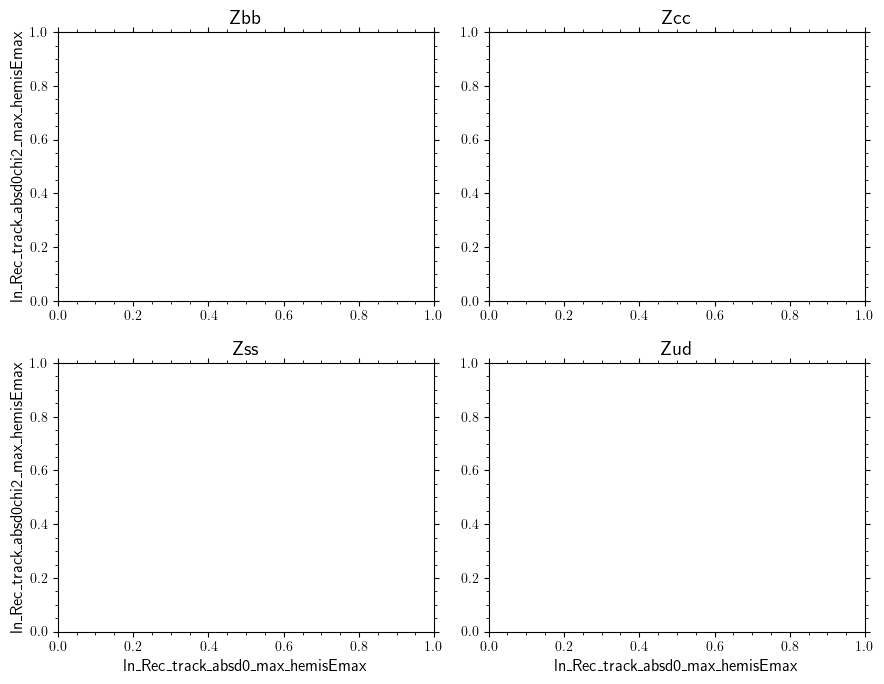

In [136]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(9,7))

df_bb = dataframe[dataframe['decay']=='p8_ee_Zbb_ecm91']
df_cc = dataframe[dataframe['decay']=='p8_ee_Zcc_ecm91']
df_ss = dataframe[dataframe['decay']=='p8_ee_Zss_ecm91'] 
df_ud = dataframe[dataframe['decay']=='p8_ee_Zud_ecm91'] 


# Big bins
axs[0, 0].set_title('Zbb')
axs[0,0].set_ylabel('ln_Rec_track_absd0chi2_max_hemisEmax')
#axs[0, 0].set_xticklabels([])
 
# Small bins
axs[0, 1].set_title('Zcc')
#axs[0, 1].set_xticklabels([])
#axs[0, 1].set_yticklabels([])


axs[1, 0].set_title('Zss')
axs[1,0].set_xlabel('ln_Rec_track_absd0_max_hemisEmax')
axs[1,0].set_ylabel('ln_Rec_track_absd0chi2_max_hemisEmax')


axs[1, 1].set_title('Zud')
axs[1,1].set_xlabel('ln_Rec_track_absd0_max_hemisEmax')
#axs[1, 1].set_yticklabels([])


h1 = axs[0, 0].hist2d(df_bb["ln_Rec_track_absd0_max_hemisEmax"], df_bb["ln_Rec_track_absd0chi2_max_hemisEmax"], bins=(50, 50), range=[ [0, 1],[0, 1]], cmap=plt.cm.Blues_r,vmin=0,vmax=100)
h2 = axs[0, 1].hist2d(df_cc["ln_Rec_track_absd0_max_hemisEmax"], df_cc["ln_Rec_track_absd0chi2_max_hemisEmax"], bins=(50, 50), range=[ [0, 1],[0, 1]], cmap=plt.cm.Blues_r,vmin=0,vmax=100)
h3 = axs[1, 0].hist2d(df_ss["ln_Rec_track_absd0_max_hemisEmax"], df_ss["ln_Rec_track_absd0chi2_max_hemisEmax"], bins=(50, 50), range=[ [0, 1],[0, 1]], cmap=plt.cm.Blues_r,vmin=0,vmax=100)
h4 = axs[1, 1].hist2d(df_ud["ln_Rec_track_absd0_max_hemisEmax"], df_ud["ln_Rec_track_absd0chi2_max_hemisEmax"], bins=(50, 50), range=[ [0, 1],[0, 1]], cmap=plt.cm.Blues_r,vmin=0,vmax=100)

# Visualizing colorbar 
fig.colorbar(h1[3], ax=axs[0, 0])
fig.colorbar(h2[3], ax=axs[0, 1])
fig.colorbar(h3[3], ax=axs[1, 0])
fig.colorbar(h4[3], ax=axs[1, 1])


plt.show()

